In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import scintools 
# import psrsigsim as pss
from scintools.scint_sim import Simulation
import scintools.ththmod as THTH
from astropy import units as u
from astropy.coordinates import SkyCoord
from scipy.signal import peak_widths
from scipy.interpolate import griddata
from mwprop.nemod.NE2025 import ne2025

from src import dmbeat
from src.psrsigsim.signal.fb_signal import FilterBankSignal
from src.psrsigsim.pulsar.profiles import GaussProfile
from src.psrsigsim.pulsar.pulsar import Pulsar
from src.psrsigsim.ism.ism import ISM
from src.rm_sim import rm_sim
from src.scint_sim import calc_params, scint_sim 
from src.spectral_index import apply_spec_idx

import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [8]:
sim = Simulation()

In [ ]:
pulsar = 'J0630-2834'
DM = 34.425
f_start = 150 # freq lower bound in MHz
f_stop = 151 # freq upper bound in MHz
veff = 77.3 # effective transverse velocity in km/s
dt = 10 # integration time in seconds
nmin = 60 # overall obs time in min

spec_idx = -1.7
ref_freq = 400 # MHz; see ATNF


RA = f'{pulsar[1:3]} {pulsar[3:5]} 00'
DEC = f'{pulsar[5:8]} {pulsar[8:10]} 00'
print(RA, DEC)

lf = f_start
rf = f_stop
cf = (lf+rf)/2
bw = rf-lf
frac_bw = bw/cf

06 30 00 -28 34 00


In [9]:
mb2, rfresnel_m, screendist_m = calc_params(RA=RA, DEC=DEC, DM=DM, cf=cf, veff=veff)

#NE2025 input: 4 parameters
   236.8691         l             (deg)                    GalacticLongitude                  
   -16.9209         b             (deg)                    GalacticLatitude                   
    34.4250         DM/D          (pc cm^{-3}_or_kpc)      Input DM or Distance               
          1         ndir          1:DM->D;-1:D->DM         Which?(DM or D)                    
#NE2025 output: 17 values
     0.4479         DIST          (kpc)                    ModelDistance                      
    34.4250         DM            (pc cm^{-3})             DispersionMeasure                  
    10.0194         DMz           (pc cm^{-3})             DM_Zcomponent                      
 7.2925e-05         SM            (kpc m^{-20/3})          ScatteringMeasure                  
 1.0165e-04         SMtau         (kpc m^{-20/3})          SM_PulseBroadening                 
 8.5411e-05         SMtheta       (kpc m^{-20/3})          SM_GalAngularBroadening         

ds 0.0006009809204456757
ns 6656
ds 0.0006009809204456757 ns 6656 time 32.28521203994751


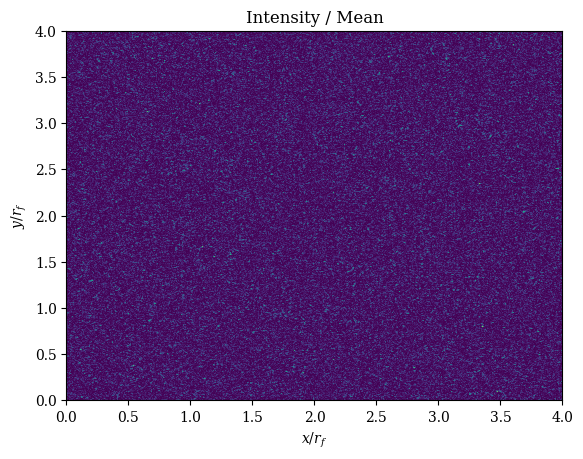

In [13]:
dspec, tlim = scint_sim(mb2, rfresnel_m, screendist_m, veff=veff, f_start=f_start, f_stop=f_stop, dt=dt, nmin=nmin, seed=3)

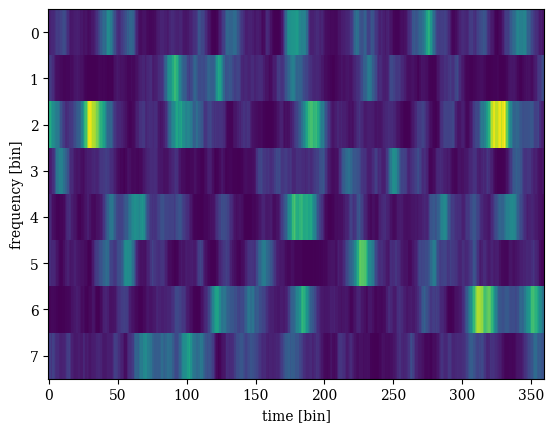

In [18]:
plt.imshow(dspec, aspect='auto', interpolation='none')
plt.ylabel('frequency [bin]')
plt.xlabel('time [bin]')
plt.show()

In [ ]:
np.savez(f'/Users/user/Downloads/dspec_{f_start}_{f_stop}_MHz.npz', dspec=dspec, tlim=tlim)

In [16]:
a = np.load('/Users/user/Downloads/dspec_100_200_MHz_072926.npz')
dspec = a['dspec'][::-1, :] # reverse frequency
tlim = a['tlim']

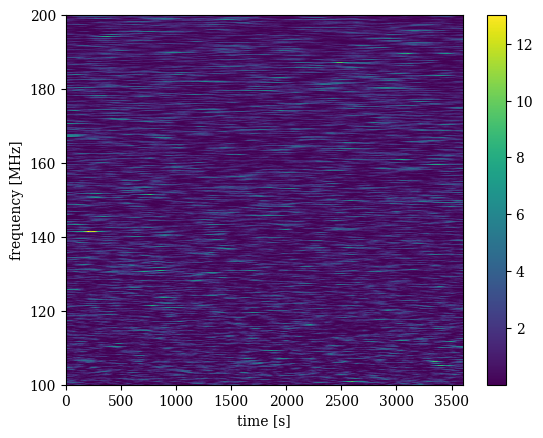

In [17]:
plt.imshow(dspec, aspect='auto', interpolation='none', extent=[0, tlim, 100, 200])
plt.ylabel('frequency [MHz]')
plt.xlabel('time [s]')
plt.colorbar()
plt.show()

In [13]:
print(dspec.shape)

(819, 360)


In [ ]:
dmbeatspec = dmbeat.dmbeat(fstart=100, fstop=200, df=0.1221, dt=10, tobs=3600, Smean=0.100,
           P=1.2, D=0.05, DM=34, psr='J0630-2834')
### this still needs to be generalized using variables from first cell

In [ ]:
np.savez('/Users/user/Downloads/dspec_dmbeat_100_200_MHz_df0.1221_dt10_073026.npz', dmbeatspec=dmbeatspec)

In [19]:
b = np.load('/Users/user/Downloads/dspec_dmbeat_100_200_MHz_df0.1221_dt10_073026.npz')
dmbeatspec = b['dmbeatspec'].T

In [20]:
print(dmbeatspec.shape)
print(dspec.shape)

(819, 359)
(819, 360)


In [30]:
freq = np.linspace(200, 100, len(dmbeatspec))

In [ ]:
dat_scint_dm_specidx = apply_spec_idx(dmbeatspec*dspec[:,:-1], freq=freq,
                                      spec_idx=spec_idx, ref_freq=ref_freq)

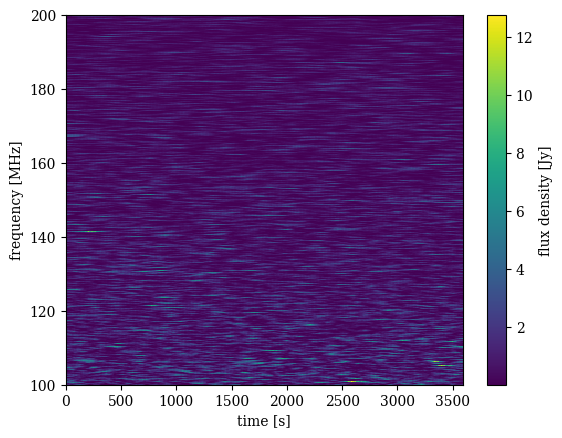

In [29]:
plt.imshow(dat_scint_dm_specidx, aspect='auto', interpolation='none', origin='upper',
           extent=[0, 3590, 100, 200])
plt.ylabel('frequency [MHz]')
plt.xlabel('time [s]')
plt.colorbar(label='flux density [Jy]')
plt.show()

In [31]:
dat_scint_dm_rm_specidx = rm_sim(dat_scint_dm_specidx, freq,
           linpol=0.6, cirpol=0., polangle=45,
           RM=45.78)

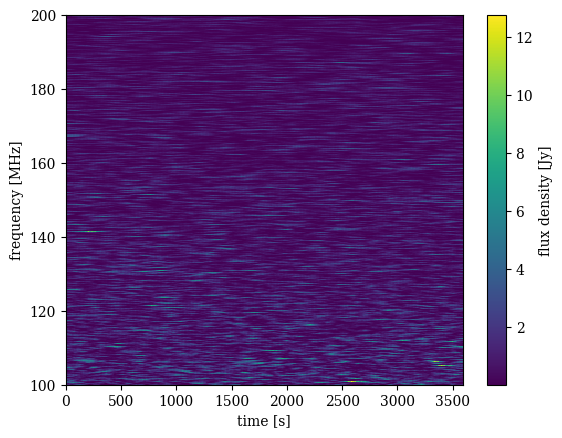

In [36]:
plt.imshow(dat_scint_dm_rm_specidx[0], aspect='auto', interpolation='none', origin='upper',
           extent=[0, 3590, 100, 200])
plt.ylabel('frequency [MHz]')
plt.xlabel('time [s]')
plt.colorbar(label='flux density [Jy]')
plt.show()

In [34]:
np.savez('/Users/user/Downloads/dat_scint_dm_rm_specidx_100_200_MHz_073026.npz', dat_scint_dm_rm_specidx=dat_scint_dm_rm_specidx,
         freq=freq, tlim=3590)
# '/Users/user/Downloads/NF_HERA_Vivaldi_efield_beam.fits'